# 멀티모달 RAG
- From CLIP to ColPali
  1. CLIP: OpenAI가 개발한 모델로, 이미지와 텍스트를 같은 벡터 공간에 매핑하는 방식으로 작동.
      - 예를 들어 "고양이 사진"이라는 텍스트와 실제 고양이 이미지가 벡터 공간에서 가까이 위치하게 학습됨.
      - 4억 개의 이미지-텍스트 쌍으로 학습되었고, 이를 통해 별도의 fine-tuning 없이도 다양한 이미지 분류·검색 작업을 수행 가능(zero-shot).
      - 멀티모달 RAG에서는 이미지와 텍스트를 동시에 검색하는 기반 기술로 활용
  2. ColPali: 기존 RAG 파이프라인의 한계를 해결하기 위해 등장한 모델
      - 기존에는 PDF에서 텍스트를 추출(OCR)하고, 표·그림은 따로 처리해야 했는데, ColPali는 PDF 페이지를 통째로 이미지로 취급해서 임베딩
      - 내부적으로는 PaliGemma(비전-언어 모델)와 ColBERT의 late interaction 메커니즘을 결합한 구조
      - 텍스트, 표, 그래프, 레이아웃 정보를 별도 파싱 없이 한 번에 인덱싱할 수 있어서 파이프라인이 훨씬 단순해지고, 특히 시각적 요소가 많은 문서에서 검색 성능이 크게 향상.

### 우리가 배웠던 RAG?
- Text RAG, 또는 Unstructured PDF 추출
  - chunking, 임베딩, 벡터 DB와 cosine similarity 검색
  - LLM에 context 주입하여 답변 생성
  - Hybrid search, reranking, evaluation 등
- 그러나, 표나 차트가 깨질 수 있으며 레이아웃이 무시됨. OCR도 오인식 가능. 페이지의 구조는 단순 텍스트 스트림이 됨.
- Text RAG 파이프라인에서 정보가 손실되는 주된 단계?
  - 원본 문서(PDF) 등에서 텍스트를 추출하는 단계에서 주요 시각 정보 손실(레이아웃, 문서 구조, 차트, 표 등)
  - 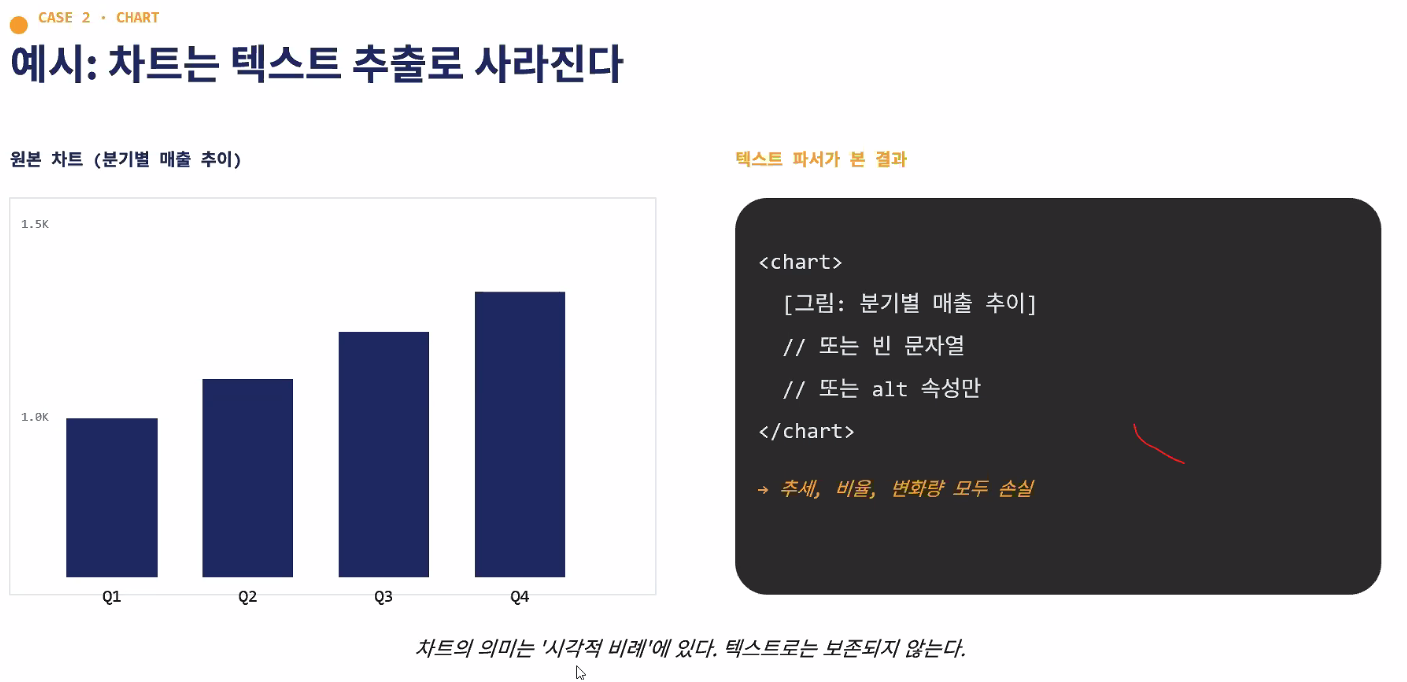
  - 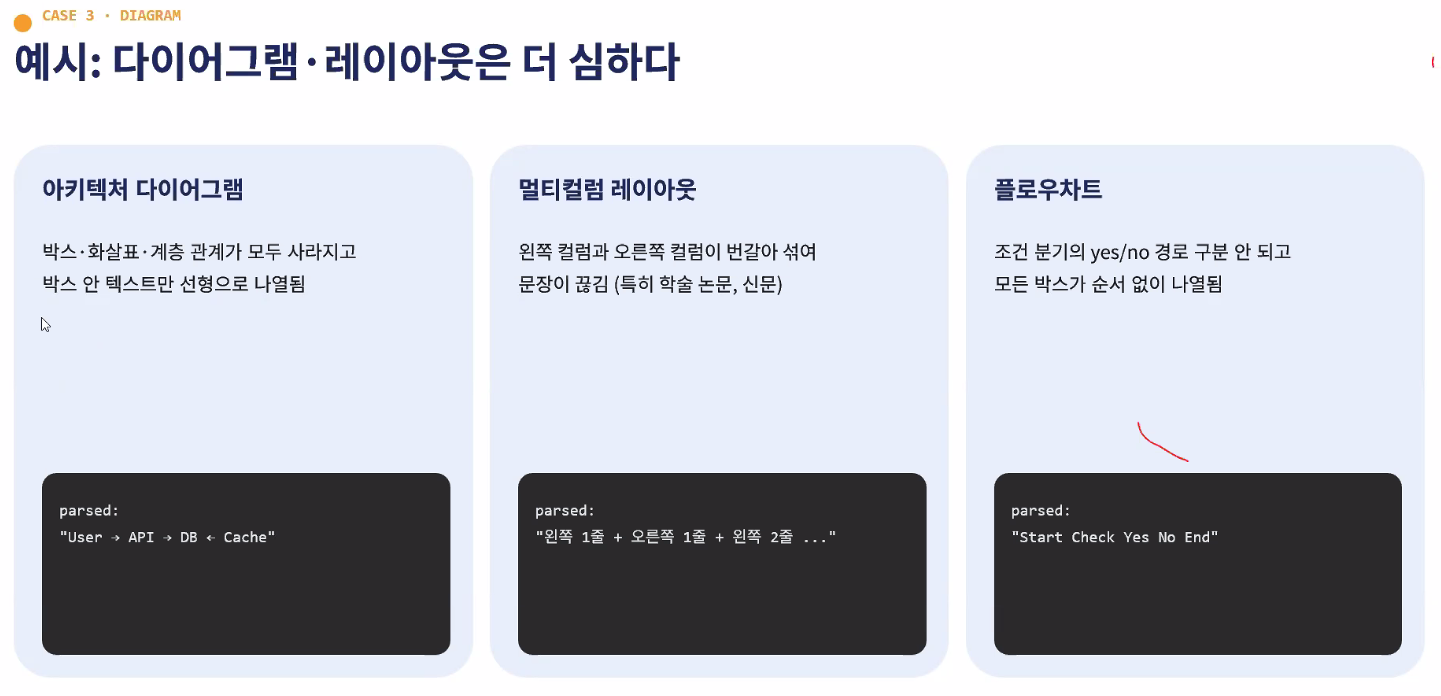


### 정보 손실의 정량화
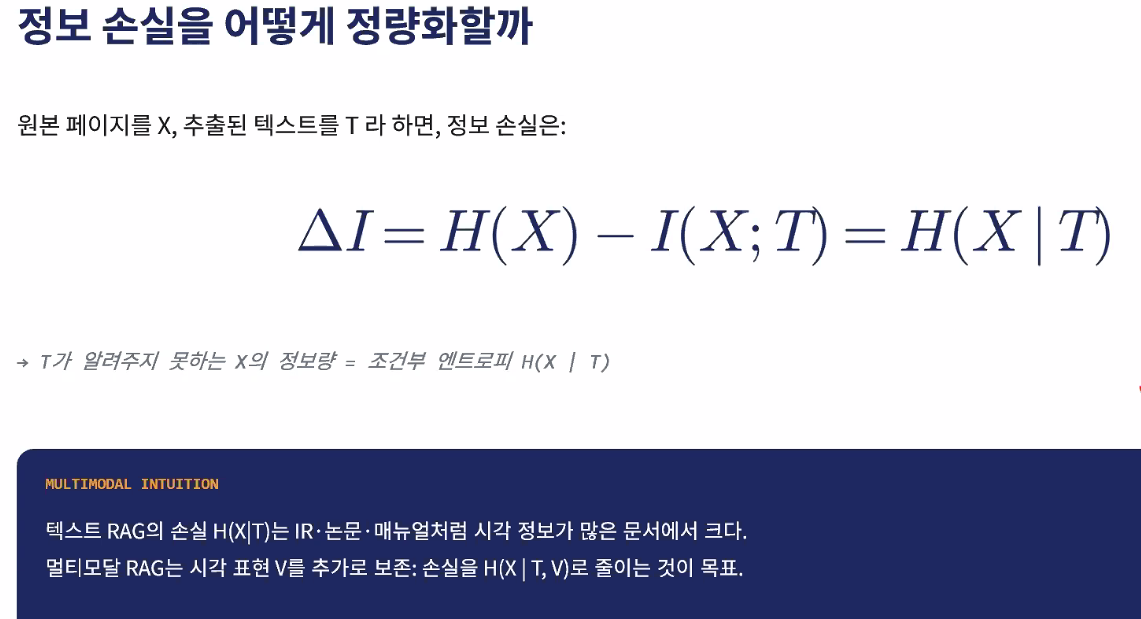
- X는 원본 페이지
- T는 페이지에서 추출된 텍스트
- 정보 손실은 H(X|T)로 정의됨
  - H는 엔트로피(불확실도)
  - H(X|T)는 T라는 조건이 있을 때 X가 될 확률
  - 즉 T만 가지고는 X를 복원할 수 없다(시각 정보, 레이아웃 등이 많이 포함되어 있을 수 있다.)

### 멀티모달 RAG란?
- 여러 모달리티 (텍스트, 이미지, 테이블, 차트, 레이아웃 등)의 의미를 보존한 채로 검색 및 생성하는 RAG. 핵심은 모달리티 간 의미를 같은 공간에서 비교하는 것.
- 구성 요소 세가지 (3개가 있어야 돌아감!)
  - 멀티모달 인코더
    - 이미지, 텍스트, 표 등을 한 벡터 공간에 매핑하는 역할(CLIP, ColPali)
  - 리트리벌 인덱스
    - 벡터 DB가 멀티모달, 멀티벡터 쿼리를 지원 (**Qdrant**, **Vespa**, Weaviate)
    - FAISS나 ChromaDB 등은 멀티모달 지원이 부족
  - 멀티모달 제네레이터
    - 텍스트와 이미지를 함께 받아 답변을 생성하는 VLM

### 멀티모달 RAG의 세가지 접근
1. 캡션 먼저 한 후 RAG
  - 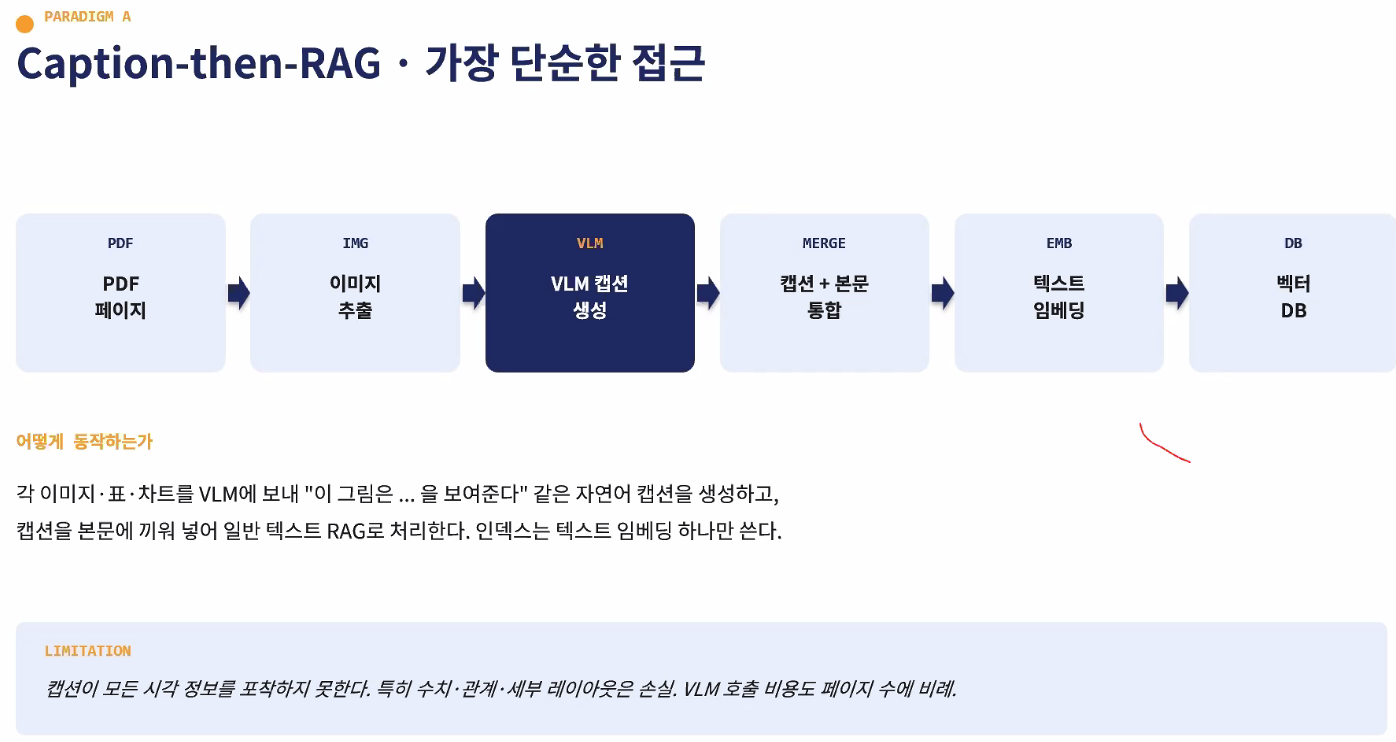
  - 이미지를 VLM을 이용해 캡션을 생성하고 -> 캡션을 텍스트 RAG로 처리
    - 장점: 단순하며 기존 RAG 재사용
    - 단점: 정보 손실 큼, VLM 비용 필요.
2. Separate-Intex
  - 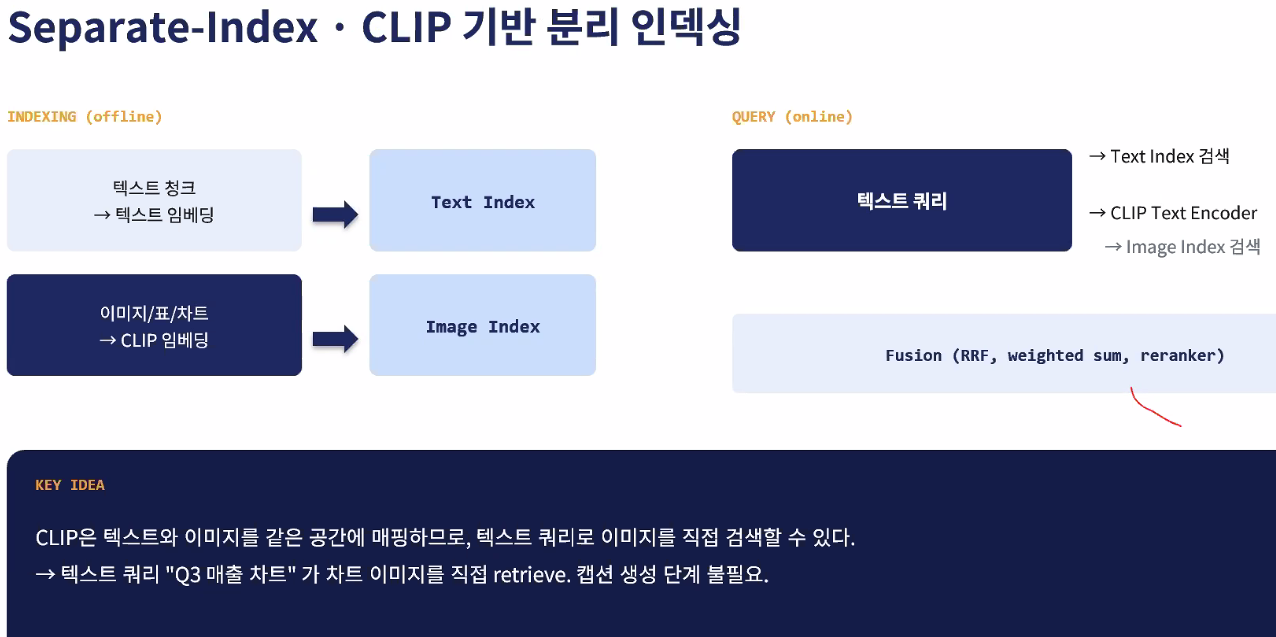
  - 텍스트는 텍스트 임베딩, 이미지는 CLIP 임베딩으로 분리하여 인덱싱
    - 장점: 각각의 모달리티 최적화
    - 단점: 두개의 인덱스 관리(텍스트 임베딩과 CLIP 등 이미지 임베딩이 따로 존재). 검색 결과를 어떻게 합쳐야 하는지 등
3. Unified Visual
  - 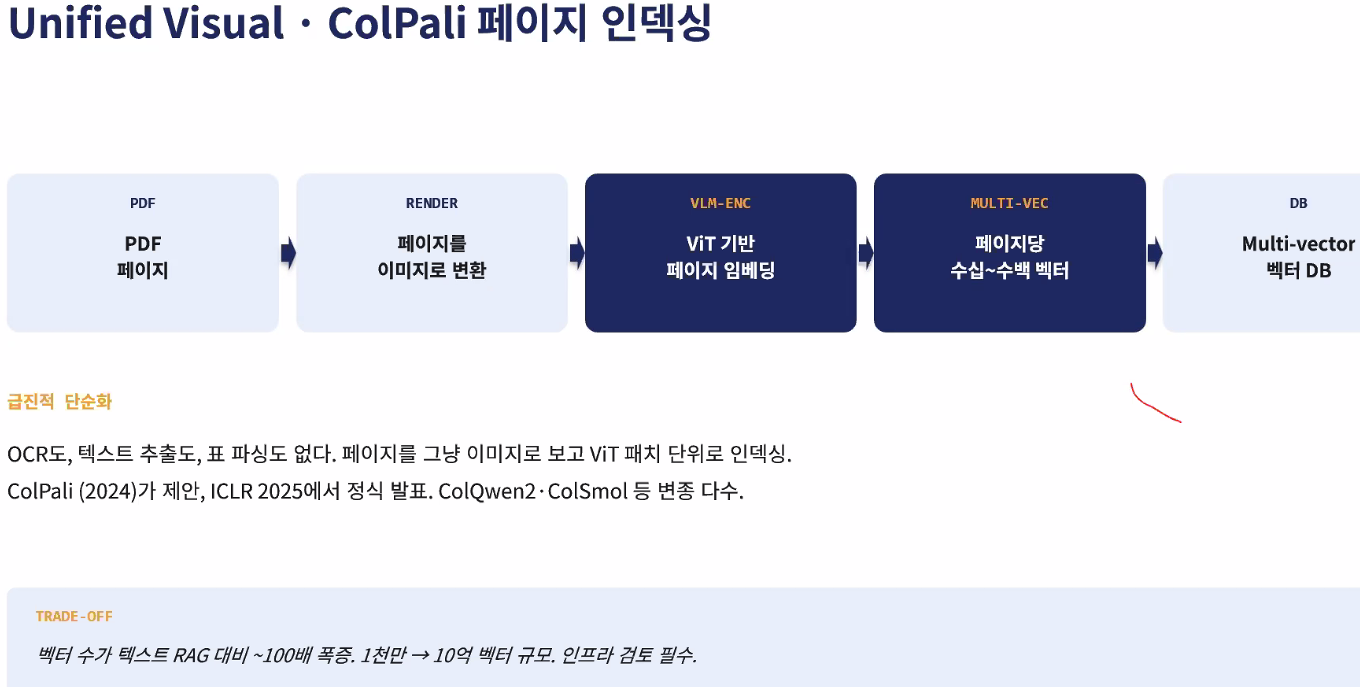
  - 페이지 자체를 이미지로 보고 ViT 기반 임베딩(ColPali 계열)
    - 장점: OCR, 파싱 불필요. 시각 정보 보존
    - 단점: 벡터 수 폭증


## 멀티모달 표현 학습
- Joint Embedding: 이미지와 텍스트 각각에 별도의 인코더를 두되, 출력 벡터를 하나의 공유 벡터 공간에 놓는 구조. "고양이 사진"과 "a photo of a cat"이 같은 공간의 가까운 점에 위치하도록 학습하는 것이 목표
  - Mutual Information (MI)
    - 두 모달리티(이미지 X, 텍스트 Y)가 공유하는 정보량을 수학적으로 정의한 것. MI가 높다 = X를 알면 Y에 대해 많이 알 수 있다 = 둘은 의미적으로 관련이 깊다. 이상적으로는 이 MI를 최대화하면 좋은 표현을 얻을 수 있음.
  - Variational Bound (ELBO)
    - 문제는 MI를 직접 계산하는 것이 사실상 불가능하다는 점(확률분포를 정확히 알 수 없으므로). 그래서 변분 추론을 통해 MI의 하한(lower bound)을 구하고, 이 하한을 대신 최대화함. "정확한 값은 모르지만, 최소 이만큼은 된다"는 보장을 올려가는 방식.
  - Contrastive Learning
    - 위의 수학적 아이디어를 실용적으로 구현한 학습 전략. 실제 쌍(positive pair, 예: 같은 의미의 이미지-텍스트)은 벡터 공간에서 가깝게, 무관한 쌍(negative pair)은 멀게 밀어내도록 학습. 배치 내의 다른 샘플들을 negative로 활용하면 별도 레이블 없이도 대규모 학습이 가능.
  - InfoNCE / Sigmoid Loss:
    - contrastive learning을 실제로 돌리기 위한 손실 함수다. InfoNCE는 CLIP이 사용한 방식으로, softmax 형태로 positive 쌍의 유사도를 나머지 negative 대비 높이도록 구성. 배치 크기가 클수록 성능이 좋지만 메모리 부담이 커짐. Sigmoid Loss(SigLIP 등)는 각 쌍을 독립적인 이진 분류로 처리하여 배치 크기 의존성을 줄인 개선 버전.

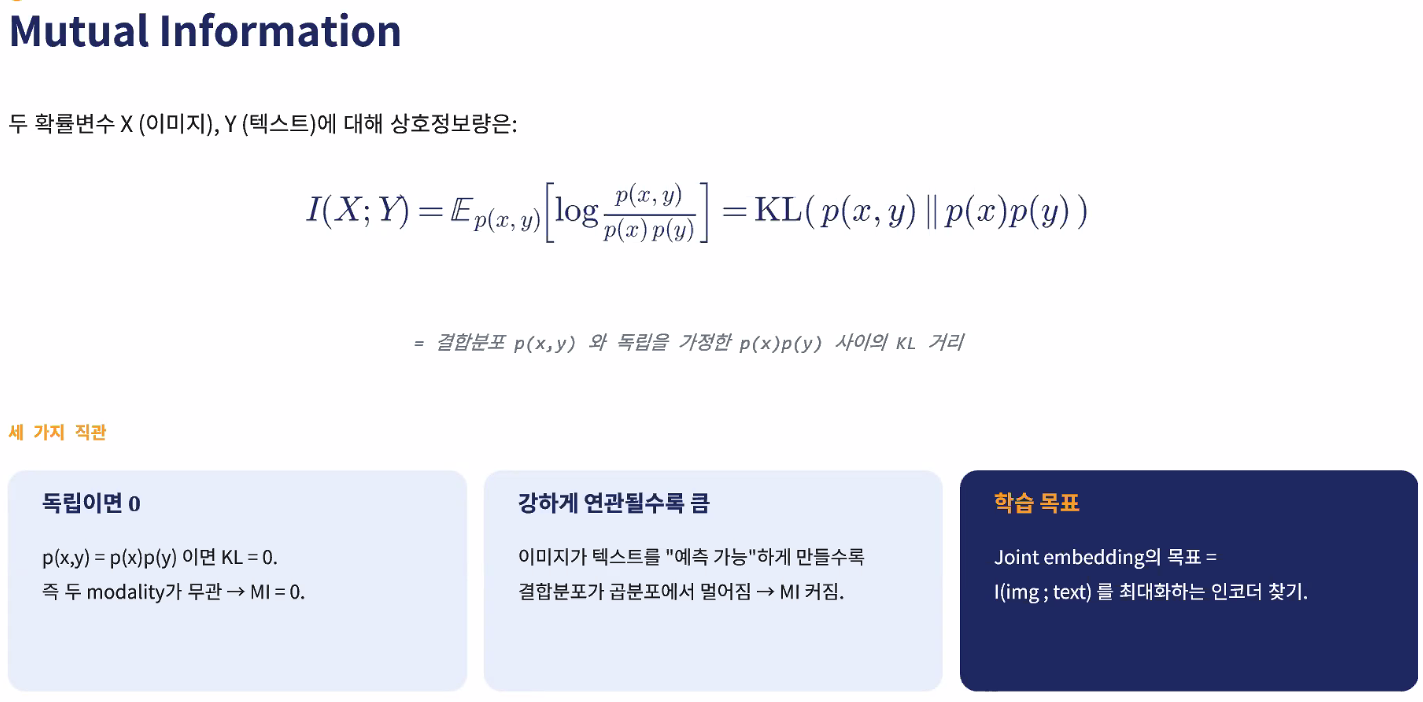

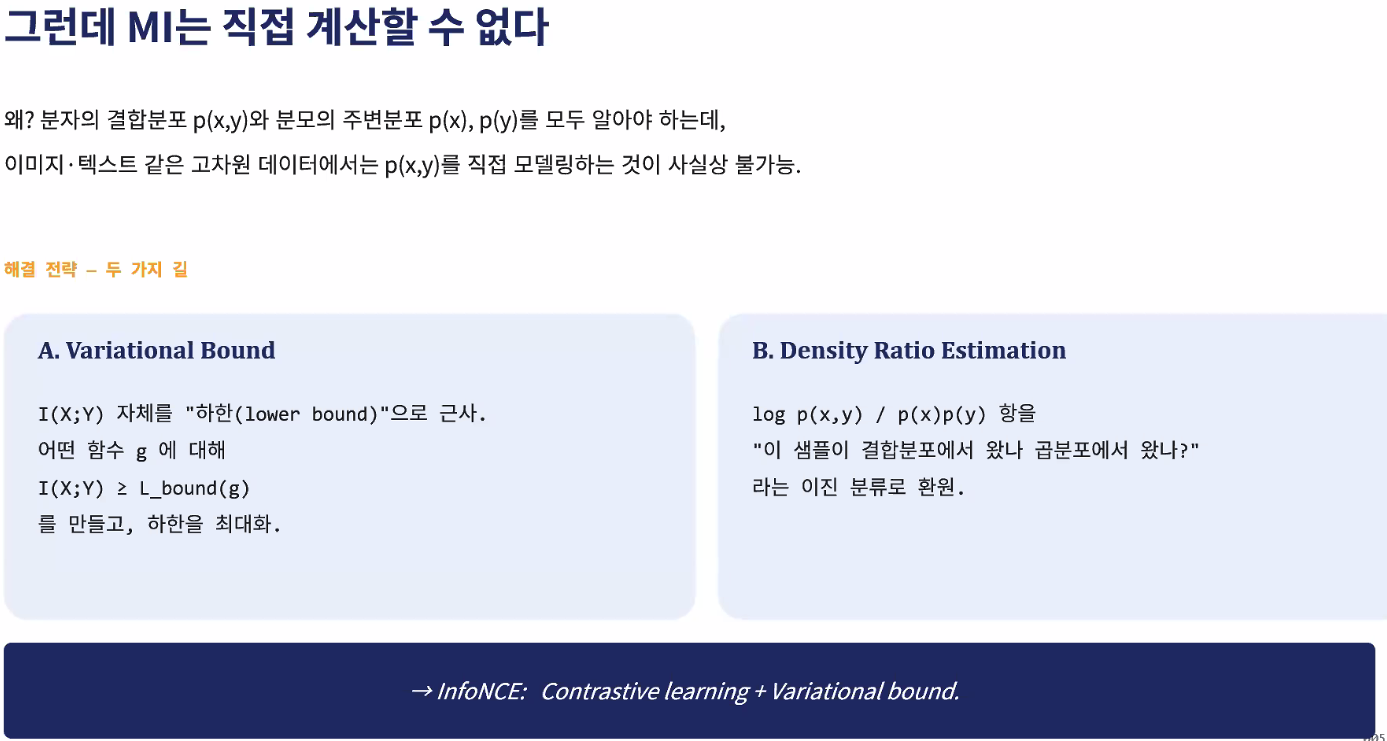

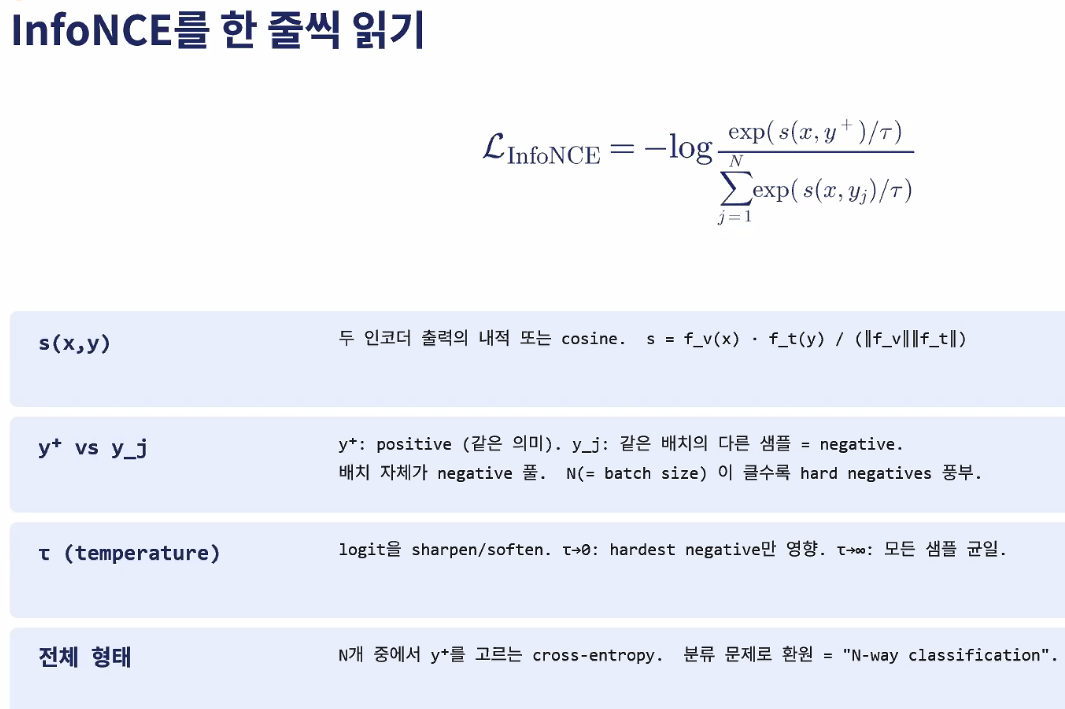

## 실습 시작 부분

In [ ]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

In [ ]:
pip install fitz

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, io, base64, re, json, math
from pathlib import Path
from typing import List, Optional, Literal
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
#import fitz  # PyMuPDF
from PIL import Image
from pydantic import BaseModel, Field
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
# from dotenv import load_dotenv
# load_dotenv()
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
llm    = ChatOpenAI(model="gpt-4o-mini")
vision = ChatOpenAI(model="gpt-4o-mini", max_tokens=500)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

/tmp/ipykernel_19602/1853148675.py:15: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [ ]:
def image_to_data_uri(image_or_path) -> str:
    if isinstance(image_or_path, (str, Path)):
        img = Image.open(image_or_path)
    else:
        img = image_or_path
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return f"data:image/png;base64,{base64.b64encode(buf.getvalue()).decode()}"

In [ ]:
IMAGE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/data/images')

img = Image.open(IMAGE_DIR / 'ir_report_page.png')
data_uri = image_to_data_uri(img)

In [ ]:
msg = HumanMessage(content =[
    {'type' : 'text', 'text' : '이 IR 보고서의 핵심 지표 3개를 한줄씩 알려줘'},
    {'type': 'image_url', 'image_url': {'url': data_uri, 'detail': 'high'}}

])

r = vision.invoke([msg])

In [ ]:
r.content

'1. **총 수익**: $1.865B, 전년 대비 18% 증가.  \n2. **운영 소득**: $245M, 전년 대비 35% 증가.  \n3. **AI 부문 수익**: $980M, 전년 대비 45% 증가.  '

In [ ]:
chart = Image.open(IMAGE_DIR / "chart_monthly_sales.png")

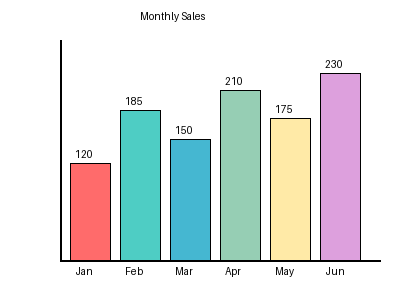

In [ ]:
chart

In [ ]:
def build_vision_message(text: str, images: list, detail: str = 'auto') -> HumanMessage:
  content = [{'type': 'text', 'text': text}]

  for img in images:
    uri = image_to_data_uri(img)
    content.append({'type':'image_url', 'image_url': {'url': uri, 'detail':detail}})

  return HumanMessage(content = content)

In [ ]:
prompts = ['이 이미지를 설명해줘', '이 막대 차트의 막대 값을 "| 월 | 값"  Markdown 표로, 마지막에 추세 한 줄 요약해줘']

for p in prompts:
  msg = build_vision_message(p, [chart], detail = 'high')
  r = vision.invoke([msg])
  print(r.content)
  print('=======')

이 이미지는 월별 판매량을 나타낸 막대 그래프입니다. 각 월에 해당하는 막대의 높이는 판매량을 표시하고 있습니다. 

- **1월**: 120
- **2월**: 185
- **3월**: 150
- **4월**: 210
- **5월**: 175
- **6월**: 230

그래프를 통해 4월과 6월에 가장 높은 판매량을 기록했음을 알 수 있으며, 전반적으로 판매량이 증가하는 추세를 보입니다. 1월이 가장 낮은 판매량을 기록했습니다.
| 월  | 값  |
|-----|-----|
| Jan | 120 |
| Feb | 185 |
| Mar | 150 |
| Apr | 210 |
| May | 175 |
| Jun | 230 |

추세 요약: 월별 판매가 전반적으로 증가하는 추세입니다.


In [ ]:
def build_extraction_prompt(image_type):
  prompts = {
      'chart' : '이 차트의 각 항목 값을 json으로 추출: {"title": "", "data": [{"label":"", "value":0}], "trend":""}',
      "invoice": '이 인보이스 정보를 json으로 추출: {"invoice_no":"", "data": "", "items" : [{"name":"", "qty":0, "total":""}], "total":""}',
      'document' : '이 문서의 정보를 json으로 추출: {"title":"", "summary":"", "key_points":[]}'
  }

  return prompts.get(image_type, '이 이미지의 핵심 내용을 3줄로 요약해주세요.')

In [ ]:
# 함수 하나 만들기
#build_extraction_prompt() # build_extraction_prompt()로 프롬프트를 만들고
# build_vision_message # 이미지 메시지를 만든 뒤

def analyze_image_typed(image_path, image_type) -> dict:
    prompt = build_extraction_prompt(image_type)

    msg = build_vision_message(
        text=prompt,
        images=[image_path],
        detail="high"
    )

    text = vision.invoke([msg]).content.strip()

    if "```" in text:
        text = text.split("```")[1].replace("json", "").strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {
            "raw_text": text,
            "error": "failed"
        }

In [ ]:
dashboard = "/content/drive/MyDrive/Colab Notebooks/data/images/dashboard_v1.png"

In [ ]:
history = [SystemMessage(content = '당신은 데이터 분석가입니다. 주어진 대시보드를 분석해주세요')]

questions = [
    "이 대시보드의 핵심 지표 3가지를 알려줘",
    "Revenue와 Order 사이의 비율은?",
    "이 추세대로면 다음 분기는 어떨까?"
]

for i, q in enumerate(questions, 1):
  if i==1:
    history.append(build_vision_message(q, [dashboard], detail='high'))
  else:
    history.append(HumanMessage(content=q))

  ans = vision.invoke(history).content
  history.append(AIMessage(content=ans))
  print(f"\n[Turn {i} Q: {q}]")
  print(f" A: {ans}")


[Turn 1 Q: 이 대시보드의 핵심 지표 3가지를 알려줘]
 A: 이 대시보드의 핵심 지표 3가지는 다음과 같습니다:

1. **Revenue (수익)**: $1.2M
2. **Orders (주문 수)**: 847
3. **Growth (성장률)**: +12% 

이 지표들은 판매 성과를 평가하는 데 중요한 역할을 합니다.

[Turn 2 Q: Revenue와 Order 사이의 비율은?]
 A: Revenue와 Orders 사이의 비율을 계산하려면 Revenue를 Orders로 나누면 됩니다.

Revenue: $1,200,000  
Orders: 847  

계산식은 다음과 같습니다:

\[
\text{비율} = \frac{\text{Revenue}}{\text{Orders}} = \frac{1,200,000}{847} \approx 1418.8
\]

따라서 Revenue와 Orders 사이의 비율은 약 1,418.8입니다. 이는 평균 주문당 수익을 나타냅니다.

[Turn 3 Q: 이 추세대로면 다음 분기는 어떨까?]
 A: 현재 월별 추세가 지속된다면 다음 분기의 성과를 추정할 수 있습니다. 

1. **Revenue (수익)**: 현재 $1.2M에서 상승세를 보이고 있으므로, 월 평균 성장은 대략 12%입니다.
2. **Orders (주문 수)**: 현재 847에서 비슷한 비율로 증가할 것으로 예상됩니다.

월별 평균 성장을 유지한다고 가정하면 다음 분기(3개월 후)에 대해 다음과 같이 예측할 수 있습니다:

- **Revenue 추정치**: 
   - 다음 분기 Revenue = $1.2M × (1 + 0.12) = $1.344M 

- **Orders 추정치**: 
   - 다음 분기 Orders = 847 × (1 + 0.12) ≈ 950

따라서, 다음 분기 예상 수익은 약 $1.344M, 주문 수는 약 950으로 예측할 수 있습니다. 이는 현재의 성장 추세가 지속된다는 가정 하에 이루어진 추정입니다.


HumanMessage(content=[{'type': 'text', 'text': '이 대시보드의 핵심 지표 3가지를 알려줘'}, {'type': 'image_url', 'image_url': {'url': '', 'detail': 'high'}}], additional_kwargs={}, response_metadata={})
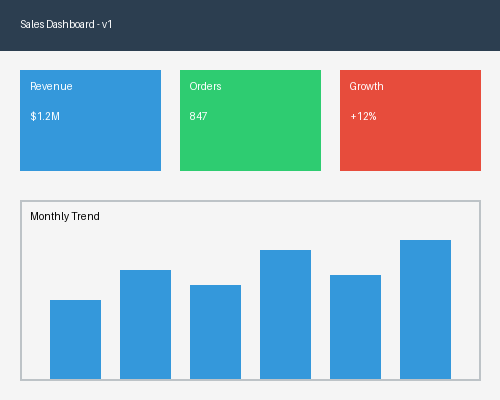

In [ ]:
def first_turn(image, message) -> HumanMessage:
    return build_vision_message(
        text=message,
        images=[image],
        detail="high"
    )

message = "이 대시보드의 핵심 지표 3가지를 알려줘"
image = "/content/drive/MyDrive/Colab Notebooks/data/images/dashboard_v1.png"

first_turn(image, message)